# Setup E - Effective Sample Size for PAT Rig NIR Measurement

Level-controlled vertical PAT rig with a side-window non-contact NIR probe, deterministic first-generation model

## Background

Setup E models a PAT (Process Analytical Technology) rig as a **vertical cylindrical sampling interface** fed continuously from an upstream manufacturing unit. A rotating outlet valve at the bottom controls discharge, while level sensors along the wall maintain the rig at approximately **half full** during operation.

The primary NIR instrument views the powder through a side optical window positioned near the lower part of the rig. In the base case used here, the measurement location is placed **one-quarter of the rig height above the bottom outlet** and the non-contact NIR spot diameter is **25 mm**.

Three distinct mass metrics are relevant:

1. **Instantaneous probed mass** ($m_{inst}$): mass simultaneously illuminated at any single instant.
2. **New mass presented per acquisition** ($m_{new}$): unique material refreshed across the NIR spot during one acquisition time, bounded by the instantaneous mass.
3. **Mass passed probe footprint** ($m_{pass}$): total mass that crosses the probe footprint during acquisition and is not bounded by the instantaneous mass.

This notebook treats the occupied lower section of the PAT rig as a first-order dense moving powder column. It uses the maintained fill level to determine whether the probe is covered by powder and then uses throughput-driven axial motion to estimate renewal at the probe position.

## Objective

Compute instantaneous probed mass, new mass presented per acquisition, and mass passed the NIR spot footprint for a level-controlled PAT rig configuration. Use a half-filled base case with the measurement window located one-quarter of the rig height from the bottom, sweep acquisition time and throughput, and export results using the standard reporting workflow.

## Theory

### Level-controlled PAT rig geometry

The PAT rig is modeled as a vertical cylinder of total height $H_{rig}$ and internal diameter $D_{pipe}$. The level-control system maintains an approximately constant filled fraction $f_{fill}$, so the modeled filled height is:

$$H_{fill} = f_{fill} \, H_{rig}$$

The NIR measurement location is placed at height $z_{probe}$ above the outlet. A simple coverage indicator is then used:

$$C_{probe} = \begin{cases}1, & z_{probe} \le H_{fill} \\ 0, & z_{probe} > H_{fill}\end{cases}$$

In the base case, the probe sits below the maintained fill level, so the optical window is treated as continuously covered by powder.

### Throughput-driven axial velocity

Within the occupied lower section of the PAT rig, powder motion near the probe is approximated as a first-order dense moving column. The axial velocity is estimated from throughput and the full cylindrical cross-section:

$$v = \frac{\dot{m}}{\rho_{bulk} \cdot A_{pipe}}$$

where

$$A_{pipe} = \pi \left(\frac{D_{pipe}}{2}\right)^2$$

This is still a simplifying assumption: it ignores detailed wall slip, outlet-valve kinematics, and any nonuniform velocity profile near the probe.

### Instantaneous probed mass

The non-contact NIR spot is represented as a circular optical footprint with area:

$$A_{spot} = \pi \left(\frac{D_{spot}}{2}\right)^2$$

The instantaneous probed mass, if the probe is covered, is:

$$m_{inst} = C_{probe} \, \rho_{bulk} \cdot A_{spot} \cdot d_{pen}$$

### Axial advance and refresh fraction

Axial advance during one acquisition is:

$$\Delta z = v \cdot T_{acq}$$

The axial sampling length is represented by a proxy length $L_{axial}$. In the base case this is taken as the NIR spot diameter. The refresh fraction is then:

$$f_{refresh} = C_{probe} \, \min\!\left(1,\;\frac{\Delta z}{L_{axial}}\right)$$

### New mass and mass passed

New mass presented per acquisition is:

$$m_{new} = f_{refresh} \cdot m_{inst}$$

Mass passed the probe footprint during acquisition is:

$$m_{pass} = C_{probe} \, \rho_{bulk} \cdot A_{spot} \cdot v \cdot T_{acq}$$

Symbols and units:

- $\dot{m}$: mass flow rate [g/s]
- $\rho_{bulk}$: bulk density [g/cm$^3$]
- $A_{pipe}$: pipe cross-section area [cm$^2$]
- $H_{rig}$: total rig height [cm]
- $f_{fill}$: maintained filled fraction [-]
- $H_{fill}$: modeled filled height [cm]
- $z_{probe}$: probe height above the outlet [cm]
- $C_{probe}$: probe coverage indicator [-]
- $A_{spot}$: NIR spot area [cm$^2$]
- $D_{spot}$: NIR spot diameter [cm]
- $d_{pen}$: measurement (penetration) depth [cm]
- $T_{acq}$: spectral acquisition time [s]
- $L_{axial}$: axial sampling length proxy [cm]

## Assumptions

- vertical cylindrical PAT rig with top feed and bottom discharge through a rotating outlet valve
- level sensors maintain an approximately constant filled fraction during operation
- the occupied lower section is treated as a dense moving powder column near the probe
- powder velocity at the probe is approximated from throughput and full pipe cross-section
- the NIR spot is circular and viewed through a side optical window
- the probe is treated as covered whenever its height is below the modeled fill height
- measurement depth is small relative to pipe diameter
- axial sampling length is approximated by the NIR spot diameter unless overridden
- no explicit outlet-valve kinematics, turbulence, segregation, or wall-slip correction
- no detailed radiative transfer model yet

## Input Parameters

Baseline PAT rig configuration:

- pipe diameter: 10.0 cm (100 mm)
- total rig height: 80.0 cm
- maintained fill fraction: 0.50
- NIR measurement height: 20.0 cm above the outlet (one-quarter of total height)
- NIR spot diameter: 2.5 cm (25 mm)
- measurement depth: 0.1 cm (1 mm)
- bulk density: 0.3 g/cm$^3$
- throughput: 95 kg over 60 min
- acquisition time: 1.0 s
- axial sampling length model: spot diameter

Sweeps:

- acquisition time: 0.1 s to 5.0 s (20 points)
- 2D sweep: throughput 10–90 kg × acquisition time 0.1–5.0 s

Internal calculations use CGS units.

In [1]:
import math
from dataclasses import dataclass
from typing import Iterable, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
@dataclass(frozen=True)
class BaseParams:
    # Geometry
    pipe_diameter_cm: float = 10.0
    total_rig_height_cm: float = 80.0
    maintained_fill_fraction: float = 0.5
    probe_height_from_bottom_cm: float = 20.0
    nir_spot_diameter_cm: float = 2.5
    measurement_depth_cm: float = 0.1  # 1 mm = 0.1 cm

    # Material
    bulk_density_g_per_cm3: float = 0.3

    # Throughput (mass flow)
    throughput_kg: float = 95.0
    throughput_time_s: float = 60.0 * 60.0  # 60 minutes

    # If set, overrides velocity derived from throughput (units: cm/s)
    velocity_override_cm_s: Optional[float] = None

    # Spectral acquisition time (seconds)
    acquisition_time_s: float = 1.0

    # Refresh model: axial sampling length proxy
    # "spot_diameter" or "custom"
    axial_length_model: str = "spot_diameter"
    axial_length_custom_cm: float = 2.5  # used if axial_length_model == "custom"


# Baseline scenario
base = BaseParams()

# Input summary table
input_summary_df = pd.DataFrame(
    {
        "parameter": [
            "pipe_diameter_cm",
            "total_rig_height_cm",
            "maintained_fill_fraction",
            "probe_height_from_bottom_cm",
            "nir_spot_diameter_cm",
            "measurement_depth_cm",
            "bulk_density_g_per_cm3",
            "throughput_kg",
            "throughput_time_s",
            "acquisition_time_s",
            "axial_length_model",
        ],
        "value": [
            base.pipe_diameter_cm,
            base.total_rig_height_cm,
            base.maintained_fill_fraction,
            base.probe_height_from_bottom_cm,
            base.nir_spot_diameter_cm,
            base.measurement_depth_cm,
            base.bulk_density_g_per_cm3,
            base.throughput_kg,
            base.throughput_time_s,
            base.acquisition_time_s,
            base.axial_length_model,
        ],
    }
)

input_summary_df

,parameter,value
0,pipe_diameter_cm,10.0
1,probe_window_diameter_cm,0.5
2,measurement_depth_cm,0.1
3,bulk_density_g_per_cm3,0.3
4,throughput_kg,95.0
5,throughput_time_s,3600.0
6,acquisition_time_s,1.0
7,axial_length_model,window_diameter


In [ ]:
def area_circle_cm2(d_cm: float) -> float:
    r = d_cm / 2.0
    return math.pi * r * r


def throughput_to_velocity_cm_s(
    pipe_diameter_cm: float,
    bulk_density_g_per_cm3: float,
    throughput_kg: float,
    throughput_time_s: float,
) -> float:
    if pipe_diameter_cm <= 0:
        raise ValueError("pipe_diameter_cm must be > 0")
    if bulk_density_g_per_cm3 <= 0:
        raise ValueError("bulk_density_g_per_cm3 must be > 0")
    if throughput_kg < 0:
        raise ValueError("throughput_kg must be >= 0")
    if throughput_time_s <= 0:
        raise ValueError("throughput_time_s must be > 0")

    mdot_g_s = (throughput_kg * 1000.0) / throughput_time_s
    vdot_cm3_s = mdot_g_s / bulk_density_g_per_cm3
    A_pipe_cm2 = area_circle_cm2(pipe_diameter_cm)
    return vdot_cm3_s / A_pipe_cm2


def filled_height_cm(params: BaseParams) -> float:
    if not 0.0 <= params.maintained_fill_fraction <= 1.0:
        raise ValueError("maintained_fill_fraction must be between 0 and 1")
    if params.total_rig_height_cm <= 0:
        raise ValueError("total_rig_height_cm must be > 0")
    return params.maintained_fill_fraction * params.total_rig_height_cm


def probe_coverage_factor(params: BaseParams) -> float:
    if params.probe_height_from_bottom_cm < 0:
        raise ValueError("probe_height_from_bottom_cm must be >= 0")
    if params.probe_height_from_bottom_cm <= filled_height_cm(params):
        return 1.0
    return 0.0


def axial_sampling_length_cm(params: BaseParams) -> float:
    if params.axial_length_model == "spot_diameter":
        return params.nir_spot_diameter_cm
    if params.axial_length_model == "custom":
        if params.axial_length_custom_cm <= 0:
            raise ValueError("axial_length_custom_cm must be > 0 when using custom model")
        return params.axial_length_custom_cm
    raise ValueError("axial_length_model must be 'spot_diameter' or 'custom'")


def compute_metrics(params: BaseParams) -> Dict[str, float]:
    A_pipe_cm2 = area_circle_cm2(params.pipe_diameter_cm)
    A_spot_cm2 = area_circle_cm2(params.nir_spot_diameter_cm)

    # velocity (cm/s) in the occupied lower section
    if params.velocity_override_cm_s is None:
        v_cm_s = throughput_to_velocity_cm_s(
            pipe_diameter_cm=params.pipe_diameter_cm,
            bulk_density_g_per_cm3=params.bulk_density_g_per_cm3,
            throughput_kg=params.throughput_kg,
            throughput_time_s=params.throughput_time_s,
        )
        velocity_source = "derived_from_throughput"
    else:
        if params.velocity_override_cm_s < 0:
            raise ValueError("velocity_override_cm_s must be >= 0")
        v_cm_s = params.velocity_override_cm_s
        velocity_source = "user_override"

    if params.acquisition_time_s <= 0:
        raise ValueError("acquisition_time_s must be > 0")

    H_fill_cm = filled_height_cm(params)
    coverage_factor = probe_coverage_factor(params)
    probe_is_covered = coverage_factor > 0.5
    probe_submergence_cm = H_fill_cm - params.probe_height_from_bottom_cm

    # instantaneous sampled mass (mass in view at the probe)
    V_probe_cm3 = coverage_factor * A_spot_cm2 * params.measurement_depth_cm
    m_inst_g = V_probe_cm3 * params.bulk_density_g_per_cm3

    # refresh / new mass presented over acquisition time
    L_ax_cm = axial_sampling_length_cm(params)
    dz_cm = v_cm_s * params.acquisition_time_s
    raw_refresh_fraction = 0.0 if L_ax_cm == 0 else min(1.0, dz_cm / L_ax_cm)
    f_refresh = coverage_factor * raw_refresh_fraction
    m_new_g_per_acq = f_refresh * m_inst_g

    # mass passed the NIR spot footprint during acquisition time
    m_pass_g_per_acq = coverage_factor * params.bulk_density_g_per_cm3 * A_spot_cm2 * v_cm_s * params.acquisition_time_s

    # exposure proxy (mass-time)
    m_time_g_s = m_inst_g * params.acquisition_time_s

    # derived flows for reporting
    mdot_g_s = (params.throughput_kg * 1000.0) / params.throughput_time_s
    vdot_cm3_s = mdot_g_s / params.bulk_density_g_per_cm3

    return {
        "setup": "E",
        "pipe_diameter_cm": params.pipe_diameter_cm,
        "pipe_area_cm2": A_pipe_cm2,
        "total_rig_height_cm": params.total_rig_height_cm,
        "maintained_fill_fraction": params.maintained_fill_fraction,
        "filled_height_cm": H_fill_cm,
        "probe_height_from_bottom_cm": params.probe_height_from_bottom_cm,
        "probe_submergence_cm": probe_submergence_cm,
        "probe_is_covered": probe_is_covered,
        "coverage_factor": coverage_factor,
        "nir_spot_diameter_cm": params.nir_spot_diameter_cm,
        "nir_spot_area_cm2": A_spot_cm2,
        "measurement_depth_cm": params.measurement_depth_cm,
        "bulk_density_g_per_cm3": params.bulk_density_g_per_cm3,
        "throughput_kg": params.throughput_kg,
        "throughput_time_s": params.throughput_time_s,
        "mass_flow_g_s": mdot_g_s,
        "vol_flow_cm3_s": vdot_cm3_s,
        "velocity_source": velocity_source,
        "velocity_cm_s": v_cm_s,
        "velocity_mm_s": v_cm_s * 10.0,
        "acquisition_time_s": params.acquisition_time_s,
        "axial_length_model": params.axial_length_model,
        "axial_sampling_length_cm": L_ax_cm,
        "advance_dz_cm_per_acq": dz_cm,
        "raw_refresh_fraction_per_acq": raw_refresh_fraction,
        "refresh_fraction_per_acq": f_refresh,
        "probe_volume_cm3": V_probe_cm3,
        "probe_mass_g_instant": m_inst_g,
        "probe_mass_mg_instant": m_inst_g * 1000.0,
        "new_mass_g_per_acq": m_new_g_per_acq,
        "new_mass_mg_per_acq": m_new_g_per_acq * 1000.0,
        "mass_passed_g_per_acq": m_pass_g_per_acq,
        "mass_passed_mg_per_acq": m_pass_g_per_acq * 1000.0,
        "mass_time_exposure_g_s": m_time_g_s,
        "mass_time_exposure_mg_s": m_time_g_s * 1000.0,
        "effective_sample_size_mg": m_new_g_per_acq * 1000.0,
    }

In [4]:
def linspace_list(start: float, stop: float, n: int) -> List[float]:
    if n < 2:
        return [float(start)]
    return list(np.linspace(start, stop, n))


def run_sweep(base: BaseParams, sweep: Dict[str, Iterable[float]]) -> pd.DataFrame:
    base_fields = set(base.__dataclass_fields__.keys())
    for k in sweep.keys():
        if k not in base_fields:
            raise KeyError(f"Unknown BaseParams field in sweep: '{k}'")

    keys = list(sweep.keys())
    values = [list(sweep[k]) for k in keys]
    grids = np.meshgrid(*values, indexing="ij")
    combos = np.stack([g.ravel() for g in grids], axis=1)

    rows: List[Dict[str, float]] = []
    for combo in combos:
        kwargs = {k: float(v) for k, v in zip(keys, combo)}
        p = BaseParams(**{**base.__dict__, **kwargs})
        rows.append(compute_metrics(p))

    return pd.DataFrame(rows)

## Compute Effective Sample Size Metrics

Run 1D acquisition-time sweep and 2D throughput × acquisition-time sweep.

In [5]:
# 1D sweep: acquisition time
sweep_acq = {"acquisition_time_s": linspace_list(0.1, 5.0, 20)}
df_acq = run_sweep(base, sweep_acq)

# 2D sweep: throughput x acquisition time
sweep_2d = {
    "throughput_kg": linspace_list(10, 90, 20),
    "acquisition_time_s": linspace_list(0.1, 5.0, 20),
}
df_2d = run_sweep(base, sweep_2d)

# Full results table
results_df = pd.concat([df_acq, df_2d], ignore_index=True)

results_df.head(10)

,setup,pipe_diameter_cm,pipe_area_cm2,probe_window_diameter_cm,probe_window_area_cm2,measurement_depth_cm,bulk_density_g_per_cm3,throughput_kg,throughput_time_s,mass_flow_g_s,...,probe_volume_cm3,probe_mass_g_instant,probe_mass_mg_instant,new_mass_g_per_acq,new_mass_mg_per_acq,mass_passed_g_per_acq,mass_passed_mg_per_acq,mass_time_exposure_g_s,mass_time_exposure_mg_s,effective_sample_size_mg
0,E,10.0,78.539816,0.5,0.19635,0.1,0.3,95.0,3600.0,26.388889,...,0.019635,0.00589,5.890486,0.001319,1.319444,0.006597,6.597222,0.000589,0.589049,1.319444
1,E,10.0,78.539816,0.5,0.19635,0.1,0.3,95.0,3600.0,26.388889,...,0.019635,0.00589,5.890486,0.004722,4.722222,0.023611,23.611111,0.002108,2.108174,4.722222
2,E,10.0,78.539816,0.5,0.19635,0.1,0.3,95.0,3600.0,26.388889,...,0.019635,0.00589,5.890486,0.005890,5.890486,0.040625,40.625000,0.003627,3.627299,5.890486
3,E,10.0,78.539816,0.5,0.19635,0.1,0.3,95.0,3600.0,26.388889,...,0.019635,0.00589,5.890486,0.005890,5.890486,0.057639,57.638889,0.005146,5.146425,5.890486
4,E,10.0,78.539816,0.5,0.19635,0.1,0.3,95.0,3600.0,26.388889,...,0.019635,0.00589,5.890486,0.005890,5.890486,0.074653,74.652778,0.006666,6.665550,5.890486
5,E,10.0,78.539816,0.5,0.19635,0.1,0.3,95.0,3600.0,26.388889,...,0.019635,0.00589,5.890486,0.005890,5.890486,0.091667,91.666667,0.008185,8.184676,5.890486
6,E,10.0,78.539816,0.5,0.19635,0.1,0.3,95.0,3600.0,26.388889,...,0.019635,0.00589,5.890486,0.005890,5.890486,0.108681,108.680556,0.009704,9.703801,5.890486
7,E,10.0,78.539816,0.5,0.19635,0.1,0.3,95.0,3600.0,26.388889,...,0.019635,0.00589,5.890486,0.005890,5.890486,0.125694,125.694444,0.011223,11.222926,5.890486
8,E,10.0,78.539816,0.5,0.19635,0.1,0.3,95.0,3600.0,26.388889,...,0.019635,0.00589,5.890486,0.005890,5.890486,0.142708,142.708333,0.012742,12.742052,5.890486
9,E,10.0,78.539816,0.5,0.19635,0.1,0.3,95.0,3600.0,26.388889,...,0.019635,0.00589,5.890486,0.005890,5.890486,0.159722,159.722222,0.014261,14.261177,5.890486


## Interpretation of the Simulation Table

Each row corresponds to one combination of operating parameters. Key columns:

- **filled_height_cm**: modeled powder height in the PAT rig from the maintained fill fraction
- **probe_is_covered**: whether the NIR window is below the modeled fill level
- **probe_mass_mg_instant**: mass simultaneously illuminated at any instant
- **new_mass_mg_per_acq**: unique material refreshed during one acquisition
- **mass_passed_mg_per_acq**: total mass crossing the NIR spot footprint during acquisition
- **refresh_fraction_per_acq**: fraction of the optical region replaced during acquisition
- **effective_sample_size_mg**: treated here as the refreshed new mass presented per acquisition

In [ ]:
# Baseline scenario metrics
base_metrics = compute_metrics(base)

baseline_display = pd.DataFrame(
    [
        {"metric": k, "value": f"{v:.6g}" if isinstance(v, (int, float, np.floating)) else v}
        for k, v in base_metrics.items()
        if k in [
            "filled_height_cm",
            "probe_height_from_bottom_cm",
            "probe_submergence_cm",
            "probe_is_covered",
            "velocity_mm_s",
            "probe_mass_mg_instant",
            "acquisition_time_s",
            "new_mass_mg_per_acq",
            "mass_passed_mg_per_acq",
            "refresh_fraction_per_acq",
            "effective_sample_size_mg",
        ]
    ]
)

baseline_display

,metric,value
0,velocity_mm_s,11.1998
1,acquisition_time_s,1
2,refresh_fraction_per_acq,1
3,probe_mass_mg_instant,5.89049
4,new_mass_mg_per_acq,5.89049
5,mass_passed_mg_per_acq,65.9722
6,effective_sample_size_mg,5.89049


## Plot 1: New Mass per Acquisition vs Acquisition Time

Shows how the unique mass contributing to a single spectrum changes with acquisition time for the half-filled PAT rig base case. At short acquisition times the optical region is only partially refreshed; at longer times the refresh fraction saturates at 1.0 and new mass plateaus.

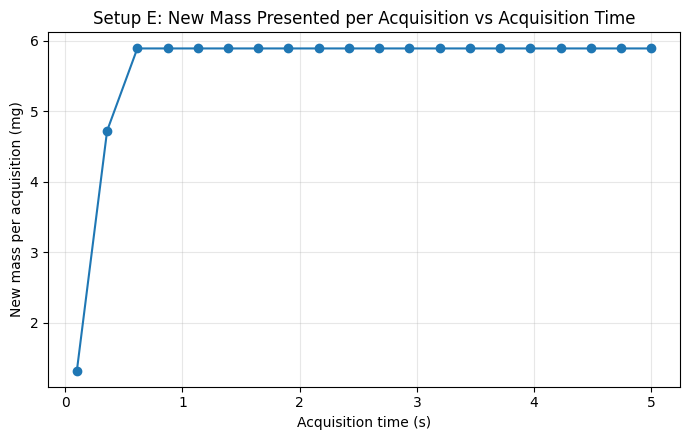

In [ ]:
df_acq_sorted = df_acq.sort_values("acquisition_time_s")

fig_new_mass, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_acq_sorted["acquisition_time_s"], df_acq_sorted["new_mass_mg_per_acq"], marker="o")
ax.set_xlabel("Acquisition time (s)")
ax.set_ylabel("New mass per acquisition (mg)")
ax.set_title("Setup E: New Mass Presented per Acquisition vs Acquisition Time\nHalf-filled PAT rig, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
fig_new_mass.tight_layout()
plt.show()

## Plot 2: Mass Passed NIR Spot Footprint vs Acquisition Time

Unlike new mass, the mass that passes the NIR spot footprint grows linearly with acquisition time and is not bounded by the instantaneous illuminated mass.

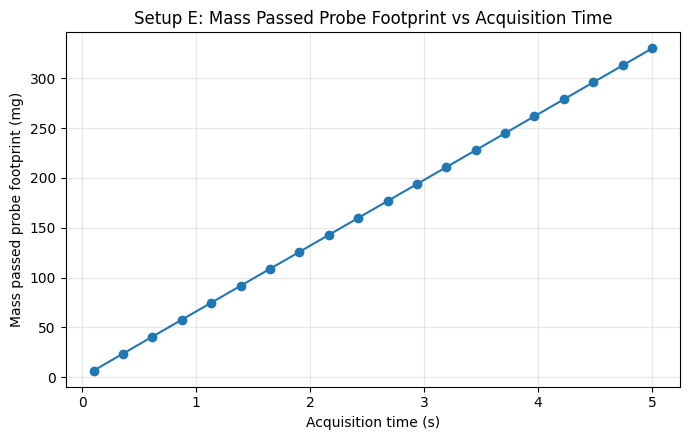

In [ ]:
fig_mass_passed, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_acq_sorted["acquisition_time_s"], df_acq_sorted["mass_passed_mg_per_acq"], marker="o")
ax.set_xlabel("Acquisition time (s)")
ax.set_ylabel("Mass passed NIR spot footprint (mg)")
ax.set_title("Setup E: Mass Passed NIR Spot Footprint vs Acquisition Time\nHalf-filled PAT rig, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
fig_mass_passed.tight_layout()
plt.show()

## Plot 3: Refresh Fraction vs Acquisition Time

The refresh fraction indicates what fraction of the optical region is replaced during one acquisition. In the base case it saturates at 1.0 when the powder advances at least one NIR spot diameter during the acquisition.

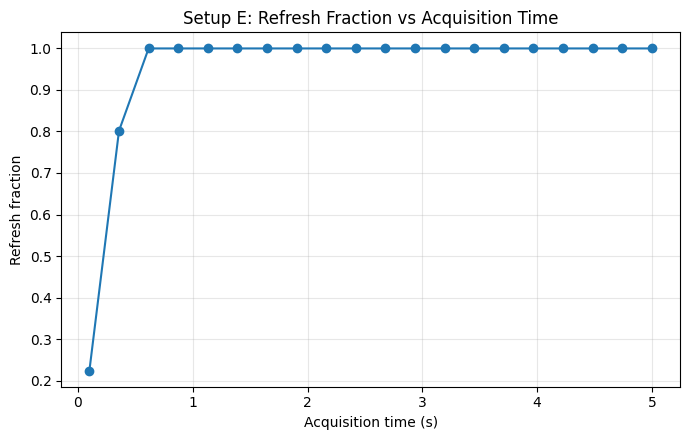

In [ ]:
fig_refresh, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(df_acq_sorted["acquisition_time_s"], df_acq_sorted["refresh_fraction_per_acq"], marker="o")
ax.set_xlabel("Acquisition time (s)")
ax.set_ylabel("Refresh fraction")
ax.set_title("Setup E: Refresh Fraction vs Acquisition Time\nHalf-filled PAT rig, 25 mm NIR spot")
ax.grid(True, alpha=0.3)
fig_refresh.tight_layout()
plt.show()

## Plot 4: Heatmap — Mass Passed NIR Spot Footprint (Throughput vs Acquisition Time)

2D sensitivity map showing how mass passed the NIR spot footprint depends jointly on throughput and acquisition time for the half-filled PAT rig base geometry.

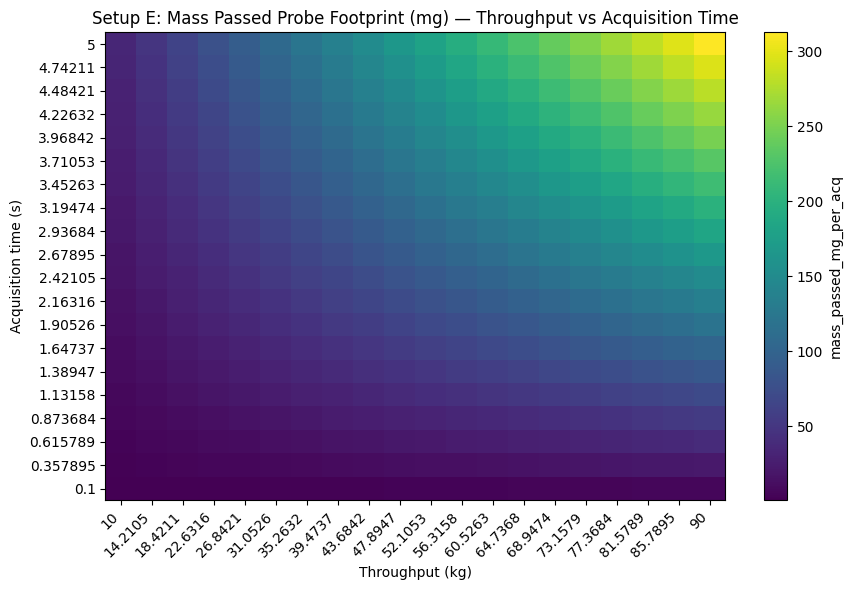

In [ ]:
pivot_mass_passed = df_2d.pivot_table(
    index="acquisition_time_s", columns="throughput_kg", values="mass_passed_mg_per_acq", aggfunc="mean"
)

fig_heatmap_mass_passed, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot_mass_passed.values, aspect="auto", origin="lower")
ax.set_xticks(np.arange(pivot_mass_passed.shape[1]))
ax.set_xticklabels([f"{v:g}" for v in pivot_mass_passed.columns], rotation=45, ha="right")
ax.set_yticks(np.arange(pivot_mass_passed.shape[0]))
ax.set_yticklabels([f"{v:g}" for v in pivot_mass_passed.index])
ax.set_xlabel("Throughput (kg)")
ax.set_ylabel("Acquisition time (s)")
ax.set_title("Setup E: Mass Passed NIR Spot Footprint (mg) — Throughput vs Acquisition Time")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("mass_passed_mg_per_acq")
fig_heatmap_mass_passed.tight_layout()
plt.show()

## Plot 5: Heatmap — New Mass per Acquisition (Throughput vs Acquisition Time)

2D sensitivity map for the refresh-based unique-mass metric under the half-filled PAT rig base geometry.

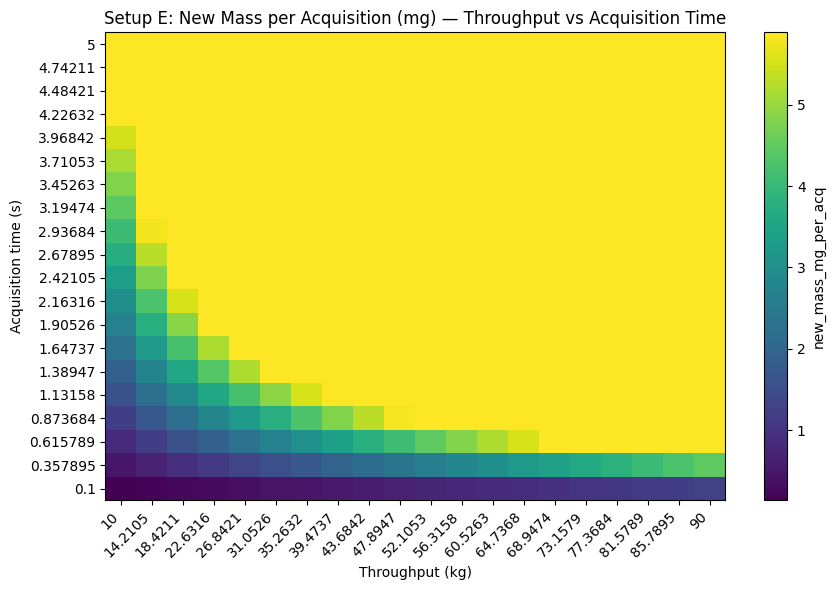

In [11]:
pivot_new_mass = df_2d.pivot_table(
    index="acquisition_time_s", columns="throughput_kg", values="new_mass_mg_per_acq", aggfunc="mean"
)

fig_heatmap_new_mass, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot_new_mass.values, aspect="auto", origin="lower")
ax.set_xticks(np.arange(pivot_new_mass.shape[1]))
ax.set_xticklabels([f"{v:g}" for v in pivot_new_mass.columns], rotation=45, ha="right")
ax.set_yticks(np.arange(pivot_new_mass.shape[0]))
ax.set_yticklabels([f"{v:g}" for v in pivot_new_mass.index])
ax.set_xlabel("Throughput (kg)")
ax.set_ylabel("Acquisition time (s)")
ax.set_title("Setup E: New Mass per Acquisition (mg) — Throughput vs Acquisition Time")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("new_mass_mg_per_acq")
fig_heatmap_new_mass.tight_layout()
plt.show()

## Results Interpretation

- in the half-filled base case, the modeled fill height remains above the measurement location, so the NIR window is treated as continuously covered
- new mass per acquisition saturates once the powder advance exceeds the 25 mm NIR spot diameter
- mass passed the NIR spot footprint grows linearly with both acquisition time and throughput
- at low throughput or short acquisition times, refresh fraction is small and the effective sample size proxy is limited
- the heatmaps reveal the operating envelope where transport renewal is most sensitive to parameter changes

## Practical Implications

- acquisition time selection trades off spectral quality against how much unique material is sampled through the side-window NIR measurement
- throughput directly controls powder velocity and therefore refresh rate near the measurement location
- maintaining the rig at approximately half full provides a simple coverage condition: the probe should remain below the fill level during normal operation
- for real-time PAT decisions, understanding whether the probe is covered and how much new material is refreshed is critical

## Limitations

- the half-filled condition is represented by a fixed fill fraction, not by an explicit level-control simulation
- the rotating outlet valve is not modeled dynamically
- the local velocity near the probe is approximated from throughput and full pipe cross-section
- no turbulence, wall-slip, or recirculation model is included
- penetration depth is an effective parameter, not a sharp optical boundary
- bulk density is assumed uniform and constant
- no particle-level sampling statistics or optical weighting correction are included

## Next Logical Extensions

- dynamic level-control and rotating-valve discharge model
- explicit dependence of local velocity on valve operation and bed holdup
- sensitivity analysis for probe height and maintained fill fraction
- uncertainty bands for measurement depth and bulk density
- non-uniform optical weighting functions for the 25 mm NIR spot

## Export and Reporting

This export section writes timestamped CSV, PNG, JSON, and Word outputs into the setup-specific `reports/` folder. `python-docx` and `nbformat` are required for Word export with Markdown rendering.

In [ ]:
from pathlib import Path
import importlib
import sys

# Resolve project root dynamically (notebooks live in <project>/notebooks/)
notebook_file = globals().get("__vsc_ipynb_file__")
if notebook_file:
    project_root = Path(notebook_file).resolve().parent.parent
else:
    project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.reporting_utils as reporting_utils
reporting_utils = importlib.reload(reporting_utils)

build_structured_word_report = reporting_utils.build_structured_word_report
create_run_directory = reporting_utils.create_run_directory
dataframe_to_markdown_table = reporting_utils.dataframe_to_markdown_table
save_dataframes_dict = reporting_utils.save_dataframes_dict
save_figures_dict = reporting_utils.save_figures_dict
write_metadata_json = reporting_utils.write_metadata_json

setup_name = "setup_e"
notebook_filename = "setup_E_PATrig_effective_sample_size.ipynb"
notebook_path = project_root / "notebooks" / notebook_filename
report_filename = "setup_e_report.docx"

timestamp, run_dir = create_run_directory(project_root, setup_name)

summary_table_df = df_acq[[
    "acquisition_time_s",
    "velocity_mm_s",
    "filled_height_cm",
    "probe_height_from_bottom_cm",
    "probe_is_covered",
    "probe_mass_mg_instant",
    "new_mass_mg_per_acq",
    "mass_passed_mg_per_acq",
    "refresh_fraction_per_acq",
    "effective_sample_size_mg",
]].copy()

dataframes_to_save = {
    "results_full": results_df,
    "summary_table": summary_table_df,
    "input_summary": input_summary_df,
}
figures_to_save = {
    "plot_01_new_mass_per_acq_vs_acquisition_time": globals().get("fig_new_mass"),
    "plot_02_mass_passed_vs_acquisition_time": globals().get("fig_mass_passed"),
    "plot_03_refresh_fraction_vs_acquisition_time": globals().get("fig_refresh"),
    "plot_04_heatmap_mass_passed_throughput_vs_acquisition": globals().get("fig_heatmap_mass_passed"),
    "plot_05_heatmap_new_mass_throughput_vs_acquisition": globals().get("fig_heatmap_new_mass"),
}

csv_files = save_dataframes_dict(dataframes_to_save, run_dir)
png_files = save_figures_dict(figures_to_save, run_dir, dpi=300)

parameter_summary = {
    "Pipe diameter (cm)": base.pipe_diameter_cm,
    "Total rig height (cm)": base.total_rig_height_cm,
    "Maintained fill fraction (-)": base.maintained_fill_fraction,
    "Modeled filled height (cm)": filled_height_cm(base),
    "Probe height from bottom (cm)": base.probe_height_from_bottom_cm,
    "NIR spot diameter (cm)": base.nir_spot_diameter_cm,
    "Measurement depth (cm)": base.measurement_depth_cm,
    "Bulk density (g/cm^3)": base.bulk_density_g_per_cm3,
    "Throughput (kg)": base.throughput_kg,
    "Throughput time (s)": base.throughput_time_s,
    "Acquisition time range (s)": "0.1 to 5.0",
    "Axial length model": base.axial_length_model,
}

metadata = {
    "setup_name": setup_name,
    "timestamp": timestamp,
    "notebook_filename": notebook_filename,
    "report_filename": report_filename,
    "report_layout": "structured_scientific_report",
    "csv_files": csv_files,
    "png_files": png_files,
    "key_parameters": parameter_summary,
}
write_metadata_json(metadata, run_dir / "metadata.json")

executive_summary_text = (
    "Setup E treats the PAT rig as a level-controlled vertical sampling interface in which a half-filled dense powder column moves past a side-window non-contact NIR measurement location. The report separates instantaneous illuminated mass, refreshed new mass, total mass passed the NIR spot footprint, and refresh fraction so that acquisition-time and throughput effects can be interpreted mechanistically for the 25 mm spot geometry rather than as a single aggregate metric."
)

worked_example_report_df = baseline_display.rename(columns={"metric": "Quantity", "value": "Value"}).copy()
worked_example_body = (
    "The baseline case below reports the maintained fill height, probe position relative to the fill level, the instantaneous mass at the probe, the refreshed new mass during one acquisition, the total mass passed the NIR spot footprint, and the resulting refresh fraction.\n\n"
    + dataframe_to_markdown_table(worked_example_report_df)
)

parameter_sweep_body = (
    "The Setup E analysis combines a one-dimensional acquisition-time sweep with a two-dimensional throughput-by-acquisition-time sweep. This lets the report distinguish time saturation effects from throughput-driven transport effects while holding the PAT rig geometry and fill level fixed.\n\n"
    "- acquisition time swept from 0.1 to 5.0 s\n"
    "- throughput swept from 10 to 90 kg over the fixed throughput-time basis\n"
    f"- maintained fill fraction fixed at {base.maintained_fill_fraction:.2f}\n"
    f"- probe height fixed at {base.probe_height_from_bottom_cm:.1f} cm from the bottom\n"
    f"- NIR spot diameter fixed at {base.nir_spot_diameter_cm:.1f} cm\n"
    f"- axial sampling length model: {base.axial_length_model}\n\n"
    f"This produces {len(results_df)} modeled rows across the 1D and 2D sweeps."
)

representative_times = [0.1, 1.0, 2.5, 5.0]
selected_rows = []
for target_time in representative_times:
    nearest_idx = (summary_table_df["acquisition_time_s"] - target_time).abs().idxmin()
    selected_rows.append(summary_table_df.loc[nearest_idx])
selected_results_report_df = pd.DataFrame(selected_rows).drop_duplicates(subset=["acquisition_time_s"]).copy()
for column in [
    "acquisition_time_s",
    "velocity_mm_s",
    "filled_height_cm",
    "probe_height_from_bottom_cm",
    "probe_mass_mg_instant",
    "new_mass_mg_per_acq",
    "mass_passed_mg_per_acq",
    "refresh_fraction_per_acq",
    "effective_sample_size_mg",
] :
    selected_results_report_df[column] = selected_results_report_df[column].map(lambda value: f"{value:.4f}")
selected_results_body = (
    "The selected table below samples representative acquisition times from the baseline sweep so the reader can compare fill condition, instantaneous illuminated mass, refreshed new mass, passed mass, refresh fraction, and the resulting effective sample-size proxy side by side.\n\n"
    + dataframe_to_markdown_table(selected_results_report_df)
)

figure_section_body = (
    "The figures are ordered from one-dimensional mechanism checks to two-dimensional operating maps: refreshed new mass, mass passed the NIR spot footprint, refresh fraction, then the throughput-acquisition heatmaps."
)
figure_entries = [
    {
        "filename": "plot_01_new_mass_per_acq_vs_acquisition_time.png",
        "caption": "Figure 1. New mass per acquisition versus acquisition time for the half-filled PAT rig base case.",
    },
    {
        "filename": "plot_02_mass_passed_vs_acquisition_time.png",
        "caption": "Figure 2. Mass passed the NIR spot footprint versus acquisition time.",
    },
    {
        "filename": "plot_03_refresh_fraction_vs_acquisition_time.png",
        "caption": "Figure 3. Refresh fraction versus acquisition time for the 25 mm NIR spot.",
    },
    {
        "filename": "plot_04_heatmap_mass_passed_throughput_vs_acquisition.png",
        "caption": "Figure 4. Throughput-acquisition heatmap for the mass passed the NIR spot footprint.",
    },
    {
        "filename": "plot_05_heatmap_new_mass_throughput_vs_acquisition.png",
        "caption": "Figure 5. Throughput-acquisition heatmap for the refresh-based new-mass metric.",
    },
]

report_sections = [
    {"source": "notebook", "heading": "## Background"},
    {"source": "notebook", "heading": "## Objective"},
    {"source": "notebook", "heading": "## Theory"},
    {"source": "notebook", "heading": "## Assumptions"},
    {"source": "notebook", "heading": "## Compute Effective Sample Size Metrics"},
    {"source": "content", "heading": "Worked example", "body": worked_example_body},
    {"source": "content", "heading": "Model scenarios and sweep design", "body": parameter_sweep_body},
    {"source": "content", "heading": "Selected results table", "body": selected_results_body},
    {"source": "content", "heading": "Figures", "body": figure_section_body, "figures": figure_entries},
    {"source": "notebook", "heading": "## Results Interpretation"},
    {"source": "notebook", "heading": "## Practical Implications"},
    {"source": "notebook", "heading": "## Limitations"},
]
appendix_sections = [
    {"source": "notebook", "heading": "## Next Logical Extensions"},
]

build_structured_word_report(
    report_title="Setup E PAT Rig Effective Sample Size Report",
    setup_name=setup_name,
    timestamp=timestamp,
    run_dir=run_dir,
    notebook_path=notebook_path,
    output_filename=report_filename,
    executive_summary_text=executive_summary_text,
    parameter_summary=parameter_summary,
    report_sections=report_sections,
    appendix_sections=appendix_sections,
    csv_filenames=csv_files,
    figure_filenames=png_files,
)

print(f"Report run directory: {run_dir}")

Report run directory: C:\temp files\EFS\reports\setup_e\20260417_150814
